# Signal Research Notebook

Interactive research and development notebook for signal creation and testing.

## Workflow
1. **Load & Explore Data** - Load market data and inspect distributions
2. **Develop Signal** - Build and test signal logic interactively
3. **Implement** - Copy validated logic to `create_signal.py`
4. **Execute** - Run `uv run create-signal` to generate `data/signal.parquet`
5. **Validate Signal** - use `uv run ew-dash` to view signal characteristics.
6. **Backtest** - Use `uv run backtest` for slurm backtest on super computer
7. **Performance** - Use `uv run opt-dash` for in depth analysis of mvo backtested signal.

## Tips
- Use cells to isolate different aspects of your signal
- Modify parameters directly in cells to test variations
- Check signal statistics regularly to catch issues early
- Document your assumptions and findings as you develop

## Setup

In [7]:
import polars as pl
import numpy as np
import datetime as dt
import sf_quant.data as sfd
import sf_quant.research as sfr
import polars_ols
import matplotlib.pyplot as plt

## 1. Load & Explore Data

Load your market data and inspect key characteristics before developing the signal.

In [8]:
T=5
days= T*21


In [ ]:
def load_data() -> pl.DataFrame:
    """
    Load and prepare market data for signal development.
    
    Returns:
        pl.DataFrame: Market data with required columns
    """
    # TODO: Load data from source (API, file, database)
    
    # TODO: Filter data as needed (date range, symbols, quality checks)

    # TODO: Inlcude Betas for backtester

    # EXAMPLE 
    
    start = dt.date(1996, 1, 1)
    end = dt.date(2024, 12, 31)
    
    crspcolumns = [
        'date',
        'cusip', 'prc', 'vol', 'shrout'
    ]
    
    crspdata= sfd.load_crsp_daily(
        start=start,
        end=end,
        columns=crspcolumns)
    
    # uses the dates for worward filling
    dates= sfd.load_crsp_daily(
        start=start,
        end=end,
        columns=['date', 'cusip'])
    dates = dates.with_columns(pl.col('date').dt.truncate('1mo').alias('month'))
    
    # calculates turnover and lags it by T months
    turnover = (crspdata.with_columns((pl.col('vol') / (pl.col('shrout') * 1000)).alias('turn'))
                        .with_columns(pl.col('date').dt.truncate('1mo').cast(pl.Date).alias('month'))
                        .group_by(['cusip','month'])
                        .agg(pl.col('turn').mean().alias('turnmonth')))
    
    turnover= turnover.sort(['cusip', 'month']).with_columns(pl.col('turnmonth').shift(1).rolling_mean(window_size=T).over('cusip').alias(f'turn{T}'))

    turnover = turnover.sort(["cusip", "month"])
    # print(turnover)
    # dates = dates.join(turnover.select(['cusip','month',f'turn{T}']),on=['cusip','month'],how='left') 
    # dates = dates.sort(['cusip','date'])
    # dates = dates.with_columns(pl.col(f'turn{T}').forward_fill().over('cusip').alias(f'turn{T}_daily'))
    
        # Ensure month columns are Date type
    dates = dates.with_columns(pl.col('month').cast(pl.Date))
    turnover = turnover.with_columns(pl.col('month').cast(pl.Date))

    # Create a complete monthly grid per cusip to avoid missing months
    all_cusips = turnover.select("cusip").unique()
    all_months = dates.select("month").unique()
    grid = all_cusips.join(all_months, how="cross")

    # Merge turnover into full grid, keeping nulls for missing months
    turnover_full = grid.join(turnover, on=["cusip","month"], how="left")

    # Compute lagged rolling mean
    turnover_full = turnover_full.sort(["cusip","month"]).with_columns(
        pl.col('turnmonth').shift(1).rolling_mean(window_size=T).over('cusip').alias(f'turn{T}')
    )

    # Join to daily dates and forward fill
    dates = dates.join(
        turnover_full.select(['cusip','month',f'turn{T}']),
        on=['cusip','month'],
        how='left'
    ).sort(['cusip','date']).with_columns(
        pl.col(f'turn{T}').forward_fill().over('cusip').alias(f'turn{T}_daily'))
    
    print(dates)
    
    columns = [
        'date',
        'cusip', 'price', 'return', 'specific_return'
    ]
    
    # print(sfd.get_assets_columns())
    
    df = sfd.load_assets(
        start=start,
        end=end,
        in_universe=True,
        columns=columns)
    
    # merge factordf onto df
    
    df = df.join(
    dates.select(['cusip','date',f'turn{T}_daily']), on=['cusip','date'], how='left')

    
    
    
    # drop every column not needed
    # turnover = turnover.drop(['turn'])
    return df

df = load_data()
df.describe()
# df.head()

shape: (34_399_400, 5)
┌────────────┬──────────┬────────────┬──────────┬─────────────┐
│ date       ┆ cusip    ┆ month      ┆ turn5    ┆ turn5_daily │
│ ---        ┆ ---      ┆ ---        ┆ ---      ┆ ---         │
│ date       ┆ str      ┆ date       ┆ f64      ┆ f64         │
╞════════════╪══════════╪════════════╪══════════╪═════════════╡
│ 2014-10-03 ┆ 00030710 ┆ 2014-10-01 ┆ null     ┆ null        │
│ 2014-10-06 ┆ 00030710 ┆ 2014-10-01 ┆ null     ┆ null        │
│ 2014-10-07 ┆ 00030710 ┆ 2014-10-01 ┆ null     ┆ null        │
│ 2014-10-08 ┆ 00030710 ┆ 2014-10-01 ┆ null     ┆ null        │
│ 2014-10-09 ┆ 00030710 ┆ 2014-10-01 ┆ null     ┆ null        │
│ …          ┆ …        ┆ …          ┆ …        ┆ …           │
│ 2008-08-08 ┆ Y2718360 ┆ 2008-08-01 ┆ 0.006638 ┆ 0.006638    │
│ 2008-08-11 ┆ Y2718360 ┆ 2008-08-01 ┆ 0.006638 ┆ 0.006638    │
│ 2008-08-12 ┆ Y2718360 ┆ 2008-08-01 ┆ 0.006638 ┆ 0.006638    │
│ 2008-08-13 ┆ Y2718360 ┆ 2008-08-01 ┆ 0.006638 ┆ 0.006638    │
│ 2008-08-14 ┆ Y2

statistic,date,cusip,price,return,specific_return,turn5_daily
str,str,str,f64,f64,f64,f64
"""count""","""21469931""","""21469931""",2.1469931e7,2.1469931e7,2.1469929e7,0.0
"""null_count""","""0""","""0""",0.0,0.0,2.0,2.1469931e7
"""mean""","""2010-07-29 00:27:41.649979""",null,40.338309,0.048704,-0.002633,null
"""std""",null,null,97.808367,3.496247,2.973566,null
"""min""","""1996-01-02""","""000307108""",0.0022,-99.8143,-103.725,null
"""25%""","""2003-05-19""",null,13.14,-1.2626,-1.007,null
"""50%""","""2010-08-11""",null,24.64,0.0,-0.042,null
"""75%""","""2017-10-25""",null,43.08,1.2736,0.926,null
"""max""","""2024-12-31""","""Y95308105""",9924.4,880.0,877.419,null


## 2. Signal Development

Build and test your signal logic. Modify parameters and logic here to find optimal configurations.

In [20]:
def create_signal(df: pl.DataFrame) -> pl.DataFrame:
    """
    Create signal based on market data.
    
    Args:
        df: Market data DataFrame
        
    Returns:
        pl.DataFrame: DataFrame with signal column added
    """

    

    df = df.with_columns((pl.col('specific_return').truediv(100)).alias('specific_return')) #return space
    df = df.with_columns((pl.col('return').truediv(100)).alias('return')) #return space
    # log ret- maybe useful later
    # df = df.with_columns((1 + pl.col('return')).log().alias('logret'))
    # df = df.with_columns((1 + pl.col('specific_return')).log().alias('logsperet'))

    # calculates momentum
    df = df.with_columns(pl.col('return').log1p().shift(21).rolling_sum(window_size=days+(12*21)).over('cusip').alias('mom'))
    
    
    
    # update vol calculation
    # cluculate vol and skew for period 1
    df = df.with_columns(pl.col('specific_return').shift(days).alias('shifret'))
    df = df.with_columns((pl.col('shifret')).rolling_std(window_size=days).over('cusip').alias('per1iv')) #finds the idiosyncratic std
    df = df.with_columns((pl.col('shifret')**3).rolling_mean(window_size=days).over('cusip').alias('per1is')) 
    df = df.with_columns((pl.col("per1is") / pl.col("per1iv")**3).over("cusip").alias("per1is"))
    
    # cluculate vol and skew for period 2
    df = df.with_columns((pl.col('specific_return')).rolling_std(window_size=days).over('cusip').alias('per2iv')) #finds the idiosyncratic std
    df = df.with_columns((pl.col('specific_return')**3).rolling_mean(window_size=days).over('cusip').alias('per2is')) 
    df = df.with_columns((pl.col("per2is") / pl.col("per2iv")**3).over("cusip").alias("per2is"))
    # df= df.drop('per2iv')
    df = df.drop_nulls(["per1is", "per1iv", "per2is", "mom"])
    # run regression to Betas using date from period 1 to skewness of predict  2
    print(df)
    
    result = (
    df.group_by("cusip")
    .agg(
        pl.col("per2is")
        .least_squares.ols(
            pl.col(["per1is","per1iv", "mom"]),
            mode="coefficients",
            add_intercept=True
        ).alias("coefficients")))
    
    result_expanded = (result.unnest("coefficients").rename({
        "per1is": "Bskew",
        "per1iv": "Bvol",
        "mom": "Bmom",
        "const": "Intercept"}))
    # use betas to predict futurn skewness 

    df = df.join(result_expanded, on='cusip', how='left')
    df = df.with_columns((pl.col('Intercept') + pl.col('per2is')*pl.col('Bskew') + pl.col('per2iv')*pl.col('Bvol') + pl.col('Bmom')*pl.col('mom')).alias('Expecskew'))
    
    
    return df

signal = create_signal(df)
# signal.head()
signal
# signal.head(1000)

shape: (17_157_349, 12)
┌────────────┬───────────┬───────┬───────────┬───┬──────────┬───────────┬──────────┬───────────┐
│ date       ┆ cusip     ┆ price ┆ return    ┆ … ┆ per1iv   ┆ per1is    ┆ per2iv   ┆ per2is    │
│ ---        ┆ ---       ┆ ---   ┆ ---       ┆   ┆ ---      ┆ ---       ┆ ---      ┆ ---       │
│ date       ┆ str       ┆ f64   ┆ f64       ┆   ┆ f64      ┆ f64       ┆ f64      ┆ f64       │
╞════════════╪═══════════╪═══════╪═══════════╪═══╪══════════╪═══════════╪══════════╪═══════════╡
│ 2015-01-29 ┆ 602496101 ┆ 8.5   ┆ 0.015532  ┆ … ┆ 0.022067 ┆ 0.868288  ┆ 0.028436 ┆ -1.019688 │
│ 2015-01-30 ┆ 602496101 ┆ 8.155 ┆ -0.040588 ┆ … ┆ 0.021969 ┆ 0.889551  ┆ 0.028545 ┆ -1.015713 │
│ 2015-02-02 ┆ 602496101 ┆ 8.07  ┆ -0.010423 ┆ … ┆ 0.021964 ┆ 0.889133  ┆ 0.028541 ┆ -1.015996 │
│ 2015-02-03 ┆ 602496101 ┆ 8.32  ┆ 0.030979  ┆ … ┆ 0.021949 ┆ 0.889493  ┆ 0.028754 ┆ -0.972146 │
│ 2015-02-04 ┆ 602496101 ┆ 8.25  ┆ -0.008413 ┆ … ┆ 0.021948 ┆ 0.899062  ┆ 0.028714 ┆ -0.978257 │
│ …   

date,cusip,price,return,specific_return,turn5_daily,mom,shifret,per1iv,per1is,per2iv,per2is,Bskew,Bvol,Bmom,Intercept,Expecskew
date,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
2015-01-29,"""602496101""",8.5,0.015532,-0.00521,null,0.588143,0.0421,0.022067,0.868288,0.028436,-1.019688,-0.102986,-24.468092,0.404951,0.794103,0.441509
2015-01-30,"""602496101""",8.155,-0.040588,-0.02692,null,0.571866,-0.00917,0.021969,0.889551,0.028545,-1.015713,-0.102986,-24.468092,0.404951,0.794103,0.431839
2015-02-02,"""602496101""",8.07,-0.010423,0.00438,null,0.601235,-0.0063,0.021964,0.889133,0.028541,-1.015996,-0.102986,-24.468092,0.404951,0.794103,0.443857
2015-02-03,"""602496101""",8.32,0.030979,0.03826,null,0.434107,0.01345,0.021949,0.889493,0.028754,-0.972146,-0.102986,-24.468092,0.404951,0.794103,0.366457
2015-02-04,"""602496101""",8.25,-0.008413,0.0094,null,0.416261,0.0182,0.021948,0.899062,0.028714,-0.978257,-0.102986,-24.468092,0.404951,0.794103,0.360826
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
2024-12-31,"""91060H108""",4.23,-0.025346,-0.03038,null,-0.559164,0.03216,0.046079,-0.234465,0.044955,-1.088071,0.125651,-0.059513,-0.281233,-1.213123,-1.19526
2024-12-30,"""46501C100""",5.145,-0.021863,-0.00993,null,-0.467986,0.00252,0.045821,-1.598788,0.039734,0.743454,-0.355671,0.01047,0.107854,0.224805,-0.089678
2024-12-31,"""46501C100""",5.03,-0.022352,-0.02554,null,-0.395645,-0.0349,0.045878,-1.597517,0.039674,0.750804,-0.355671,0.01047,0.107854,0.224805,-0.08449


In [21]:
# Sorts into quintiles
signal= signal.with_columns(
    pl.col("Expecskew").rank(method="average").over("date").alias("rank"))

signal = signal.with_columns(
    pl.count("Expecskew").over("date").alias("count_per_date"))

signal = signal.with_columns(
    ((pl.col("rank") / pl.col("count_per_date") * 5).ceil().cast(pl.Int32)).alias("quintile"))

signal = signal.drop(["rank", "count_per_date"])
signal.describe()
signal= signal.filter(pl.col("quintile").is_not_null())
signal

date,cusip,price,return,specific_return,turn5_daily,mom,shifret,per1iv,per1is,per2iv,per2is,Bskew,Bvol,Bmom,Intercept,Expecskew,quintile
date,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,i32
2015-01-29,"""602496101""",8.5,0.015532,-0.00521,null,0.588143,0.0421,0.022067,0.868288,0.028436,-1.019688,-0.102986,-24.468092,0.404951,0.794103,0.441509,4
2015-01-30,"""602496101""",8.155,-0.040588,-0.02692,null,0.571866,-0.00917,0.021969,0.889551,0.028545,-1.015713,-0.102986,-24.468092,0.404951,0.794103,0.431839,4
2015-02-02,"""602496101""",8.07,-0.010423,0.00438,null,0.601235,-0.0063,0.021964,0.889133,0.028541,-1.015996,-0.102986,-24.468092,0.404951,0.794103,0.443857,4
2015-02-03,"""602496101""",8.32,0.030979,0.03826,null,0.434107,0.01345,0.021949,0.889493,0.028754,-0.972146,-0.102986,-24.468092,0.404951,0.794103,0.366457,4
2015-02-04,"""602496101""",8.25,-0.008413,0.0094,null,0.416261,0.0182,0.021948,0.899062,0.028714,-0.978257,-0.102986,-24.468092,0.404951,0.794103,0.360826,4
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
2024-12-31,"""91060H108""",4.23,-0.025346,-0.03038,null,-0.559164,0.03216,0.046079,-0.234465,0.044955,-1.088071,0.125651,-0.059513,-0.281233,-1.213123,-1.19526,1
2024-12-30,"""46501C100""",5.145,-0.021863,-0.00993,null,-0.467986,0.00252,0.045821,-1.598788,0.039734,0.743454,-0.355671,0.01047,0.107854,0.224805,-0.089678,2
2024-12-31,"""46501C100""",5.03,-0.022352,-0.02554,null,-0.395645,-0.0349,0.045878,-1.597517,0.039674,0.750804,-0.355671,0.01047,0.107854,0.224805,-0.08449,2


In [22]:
ew = (signal.group_by(["date", "quintile"]).agg(pl.col("Expecskew").mean()).pivot(
        values="Expecskew",
        index="date",
        columns="quintile", sort_columns=True
    )
    .sort("date")
    .with_columns(pl.exclude('date')))
print(ew)
# dates= ew['date']

# for col in ew.columns:
#     if col != "date":
#         plt.plot(dates, ew[col], label=f"Q{col}", linewidth=0.5)

# plt.legend()
# plt.xlabel("Date")
# plt.ylim(-1,3)
# plt.ylabel("Firm Skewness")
# plt.title("Quintile Skewness")
# plt.show()


shape: (7_300, 6)
┌────────────┬───────────┬───────────┬──────────┬──────────┬───────────┐
│ date       ┆ 1         ┆ 2         ┆ 3        ┆ 4        ┆ 5         │
│ ---        ┆ ---       ┆ ---       ┆ ---      ┆ ---      ┆ ---       │
│ date       ┆ f64       ┆ f64       ┆ f64      ┆ f64      ┆ f64       │
╞════════════╪═══════════╪═══════════╪══════════╪══════════╪═══════════╡
│ 1996-01-02 ┆ null      ┆ null      ┆ null     ┆ null     ┆ -0.575942 │
│ 1996-01-03 ┆ null      ┆ null      ┆ null     ┆ null     ┆ -0.549756 │
│ 1996-01-04 ┆ null      ┆ null      ┆ null     ┆ null     ┆ -0.473428 │
│ 1996-01-05 ┆ null      ┆ null      ┆ null     ┆ null     ┆ -0.427735 │
│ 1996-01-08 ┆ null      ┆ null      ┆ null     ┆ null     ┆ -0.448469 │
│ …          ┆ …         ┆ …         ┆ …        ┆ …        ┆ …         │
│ 2024-12-24 ┆ -1.509741 ┆ -0.085832 ┆ 0.231769 ┆ 0.601318 ┆ 2.289189  │
│ 2024-12-26 ┆ -1.503429 ┆ -0.085103 ┆ 0.233291 ┆ 0.599575 ┆ 2.278151  │
│ 2024-12-27 ┆ -1.504068 ┆ -0.089

/tmp/ipykernel_1874273/1298453719.py:1: DeprecationWarning: the argument `columns` for `DataFrame.pivot` is deprecated. It was renamed to `on` in version 1.0.0.
  ew = (signal.group_by(["date", "quintile"]).agg(pl.col("Expecskew").mean()).pivot(


In [18]:
signal = signal.group_by(['date', 'quintile']).agg(pl.col('return').mean().alias('quint_ret')).sort(['quintile', 'date'])

signal = signal.with_columns(pl.col('quint_ret').log1p().cum_sum().over('quintile').alias('cum_ret'))


ew = (signal.group_by(["date", "quintile"]).agg(pl.col("cum_ret").mean()).pivot(
        values="cum_ret",
        index="date",
        columns="quintile", sort_columns=True
    )
    .sort("date")
    .with_columns(pl.exclude('date')))

ew = ew.with_columns((pl.col('1')-pl.col('5')).alias('spread'))
print(ew)

dates= ew['date']
lists= ['Q1', 'Q2', 'Q3', 'Q4', 'Q5', 'Spread']
for i in lists:
    signal = signal.with_columns(((pl.col(i) / pl.col(i).rolling_std(window_size=252).shift(1)) * np.sqrt(252)).alias(f'{i}_volscal'))
    plt.plot(dates, df[i] , label=i, linewidth=0.5)
#     if col == "spread":
#         plt.plot(dates, ew[col], label=f"Spread", linewidth=0.5)

plt.legend()
plt.xlabel("Date")
# plt.ylim(-1,1)
plt.ylabel("Cumulative Returns")
plt.title("Quintile Skewness")
plt.show()

ColumnNotFoundError: unable to find column "return"; valid columns: ["date", "quintile", "quint_ret", "cum_ret"]

Resolved plan until failure:

	---> FAILED HERE RESOLVING 'sink' <---
DF ["date", "quintile", "quint_ret", "cum_ret"]; PROJECT */4 COLUMNS

/tmp/ipykernel_1874273/430862856.py:5: DeprecationWarning: the argument `columns` for `DataFrame.pivot` is deprecated. It was renamed to `on` in version 1.0.0.
  ew = (signal.group_by(["date", "quintile"]).agg(pl.col("cum_ret").mean()).pivot(


shape: (7_300, 7)
┌────────────┬──────────┬──────────┬──────────┬──────────┬───────────┬──────────┐
│ date       ┆ 1        ┆ 2        ┆ 3        ┆ 4        ┆ 5         ┆ spread   │
│ ---        ┆ ---      ┆ ---      ┆ ---      ┆ ---      ┆ ---       ┆ ---      │
│ date       ┆ f64      ┆ f64      ┆ f64      ┆ f64      ┆ f64       ┆ f64      │
╞════════════╪══════════╪══════════╪══════════╪══════════╪═══════════╪══════════╡
│ 1996-01-02 ┆ null     ┆ null     ┆ null     ┆ null     ┆ -0.015873 ┆ null     │
│ 1996-01-03 ┆ null     ┆ null     ┆ null     ┆ null     ┆ -0.023905 ┆ null     │
│ 1996-01-04 ┆ null     ┆ null     ┆ null     ┆ null     ┆ -0.007905 ┆ null     │
│ 1996-01-05 ┆ null     ┆ null     ┆ null     ┆ null     ┆ -0.032003 ┆ null     │
│ 1996-01-08 ┆ null     ┆ null     ┆ null     ┆ null     ┆ -0.015874 ┆ null     │
│ …          ┆ …        ┆ …        ┆ …        ┆ …        ┆ …         ┆ …        │
│ 2024-12-24 ┆ 5.675708 ┆ 3.93114  ┆ 3.008953 ┆ 2.354854 ┆ 1.250248  ┆ 4.425461 

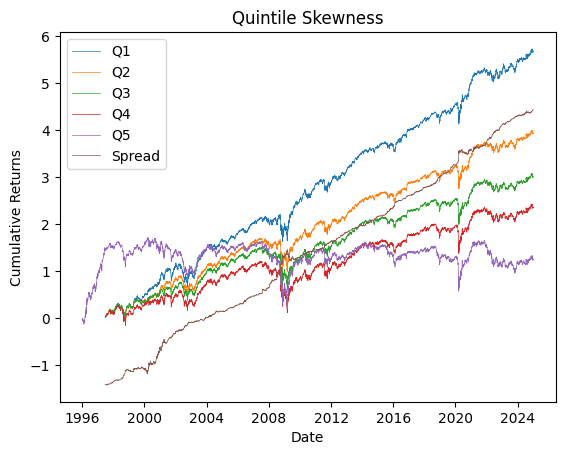

In [ ]:
signal = signal.group_by(['date', 'quintile']).agg(pl.col('return').mean().alias('quint_ret')).sort(['quintile', 'date'])

signal = signal.with_columns(pl.col('quint_ret').log1p().cum_sum().over('quintile').alias('cum_ret'))


ew = (signal.group_by(["date", "quintile"]).agg(pl.col("cum_ret").mean()).pivot(
        values="cum_ret",
        index="date",
        columns="quintile", sort_columns=True
    )
    .sort("date")
    .with_columns(pl.exclude('date')))

ew = ew.with_columns((pl.col('1')-pl.col('5')).alias('spread'))
print(ew)

dates= ew['date']

for col in ew.columns:
    if col != "date" and col != 'spread':
        plt.plot(dates, ew[col], label=f"Q{col}", linewidth=0.5)
    if col == "spread":
        plt.plot(dates, ew[col], label=f"Spread", linewidth=0.5)

plt.legend()
plt.xlabel("Date")
# plt.ylim(-1,1)
plt.ylabel("Cumulative Returns")
plt.title("Quintile Skewness")
plt.show()

In [14]:

# For old skewness
signal= signal.with_columns(
    pl.col("is").rank(method="average").over("date").alias("rank"))

signal = signal.with_columns(
    pl.count("is").over("date").alias("count_per_date"))

signal = signal.with_columns(
    ((pl.col("rank") / pl.col("count_per_date") * 5).ceil().cast(pl.Int32)).alias("quintile"))

signal = signal.drop(["rank", "count_per_date"])
signal.describe()


signal= signal.filter(pl.col("quintile").is_not_null())




ColumnNotFoundError: unable to find column "is"; valid columns: ["date", "quintile", "quint_ret", "cum_ret"]

/tmp/ipykernel_3907459/4152593547.py:1: DeprecationWarning: the argument `columns` for `DataFrame.pivot` is deprecated. It was renamed to `on` in version 1.0.0.
  ew = (signal.group_by(["date", "quintile"]).agg(pl.col("return").mean()).pivot(


ValueError: too many values to unpack (expected 2)

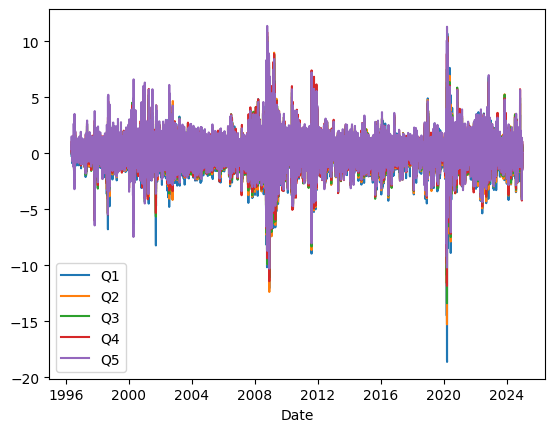

In [ ]:
ew = (signal.group_by(["date", "quintile"]).agg(pl.col("return").mean()).pivot(
        values="return",
        index="date",
        columns="quintile", sort_columns=True
    )
    .sort("date")
    .with_columns(pl.exclude('date')*100))

dates= ew['date']

for col in ew.columns:
    if col != "date":
        plt.plot(dates, ew[col], label=f"Q{col}")

plt.legend()
plt.xlabel("Date")
plt.xlim('01-01-19')
plt.ylabel("Return")
plt.title("Quintile Returns")
plt.show()


## 3. Signal Analysis

Examine signal statistics and distributions to understand its characteristics.

### Statistics

In [ ]:
sfr.get_signal_stats(signal)

ColumnNotFoundError: unable to find column "signal"; valid columns: ["date", "barrid", "price", "return", "specific_return", "daysin3mo", "iv", "is", "quintile"]

### Distribution

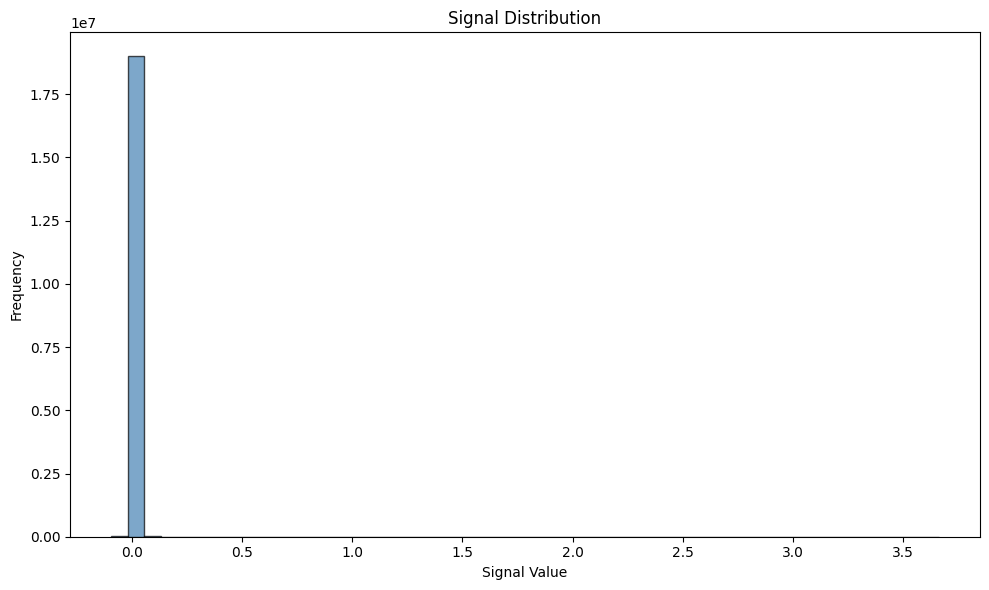

In [ ]:
sfr.get_signal_distribution(signal)

## 4. Validation Checks ?

Verify signal quality and identify any issues before implementation.

## 5. Next Steps

When satisfied with your signal:

1. **Copy** your data loading and signal calculation logic to `create_signal.py`
2. **Run** `uv run create-signal` to save the signal to `data/signal.parquet`
3. **Open** `uv run ew-dash` to analyze the signal before backtesting